# 🏠 House Price Prediction

**Objective:** Predict house prices using property features such as size, number of bedrooms, and location.

**Dataset:** House Price Prediction Dataset (Kaggle)

**Models Used:** Linear Regression, Gradient Boosting Regressor

**Evaluation Metrics:** MAE, RMSE, R² Score


---
## 1. Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Load the Dataset

> **Download:** https://www.kaggle.com/datasets/yasserh/housing-prices-dataset  
> Save the file as `Housing.csv` in the same folder as this notebook.

**Common Columns in this Dataset:**

| Column | Description |
|---|---|
| `price` | **Target** - Sale price of the house |
| `area` | Total area in square feet |
| `bedrooms` | Number of bedrooms |
| `bathrooms` | Number of bathrooms |
| `stories` | Number of floors |
| `mainroad` | Connected to main road (yes/no) |
| `guestroom` | Has a guest room (yes/no) |
| `basement` | Has a basement (yes/no) |
| `hotwaterheating` | Has hot water heating (yes/no) |
| `airconditioning` | Has air conditioning (yes/no) |
| `parking` | Number of parking spaces |
| `prefarea` | Located in preferred area (yes/no) |
| `furnishingstatus` | Furnished / semi-furnished / unfurnished |

In [2]:
df = pd.read_csv('Housing.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (545, 13)

Column names: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

First 5 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


---
## 3. Exploratory Data Analysis (EDA)


### 3.1 Basic Info and Summary Statistics

In [3]:
print("=== Dataset Info ===")
df.info()


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
print("=== Descriptive Statistics ===")
df.describe().round(2)


=== Descriptive Statistics ===


,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


In [5]:
missing = df.isnull().sum()
print("=== Missing Values ===")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")


=== Missing Values ===
No missing values found!


### 3.2 Target Variable - Price Distribution

Understanding the distribution of house prices is the first step. Skewed distributions often require log transformation.


Min price    : 1,750,000
Max price    : 13,300,000
Mean price   : 4,766,729
Median price : 4,340,000
Skewness     : 1.212  (>1 = right-skewed)


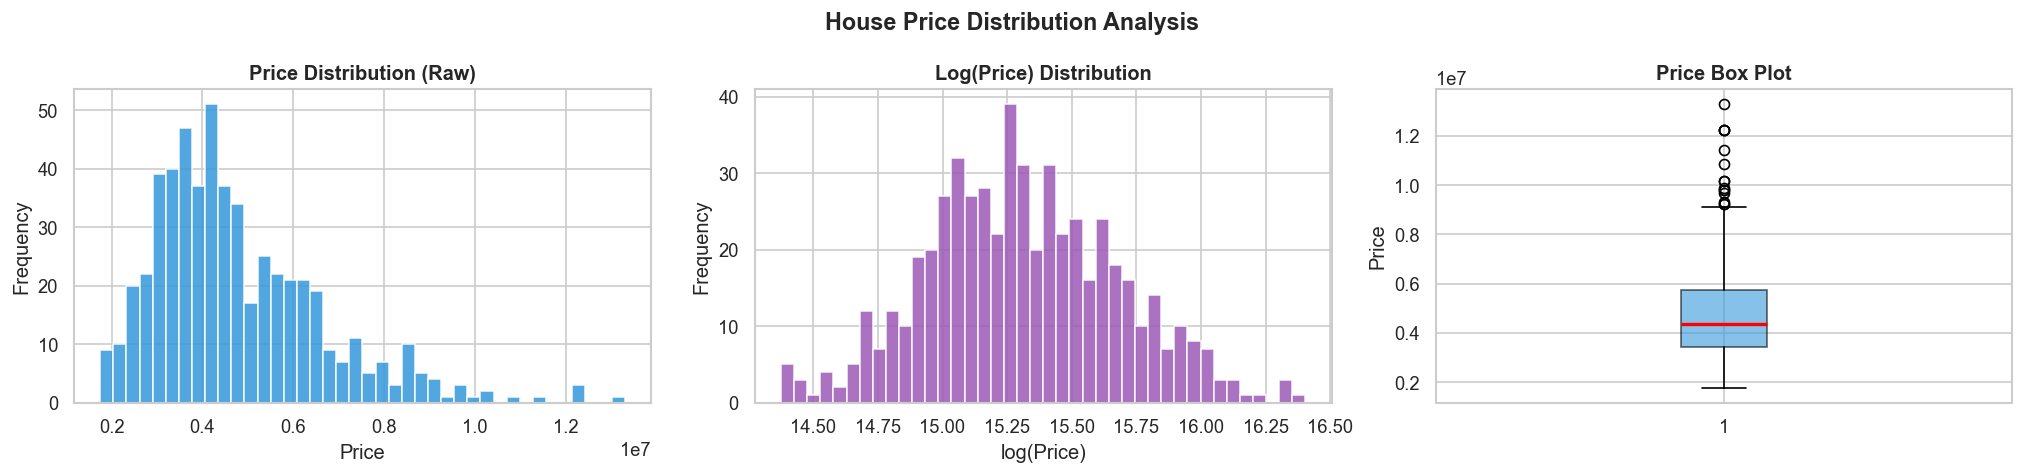

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Raw distribution
axes[0].hist(df['price'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Log-transformed
axes[1].hist(np.log1p(df['price']), bins=40, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].set_title('Log(Price) Distribution', fontweight='bold')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')

# Box plot
axes[2].boxplot(df['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6),
                medianprops=dict(color='red', lw=2))
axes[2].set_title('Price Box Plot', fontweight='bold')
axes[2].set_ylabel('Price')

plt.suptitle('House Price Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()

print(f"Min price    : {df['price'].min():,.0f}")
print(f"Max price    : {df['price'].max():,.0f}")
print(f"Mean price   : {df['price'].mean():,.0f}")
print(f"Median price : {df['price'].median():,.0f}")
print(f"Skewness     : {df['price'].skew():.3f}  (>1 = right-skewed)")

plt.savefig('hp_01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Numerical Feature Distributions


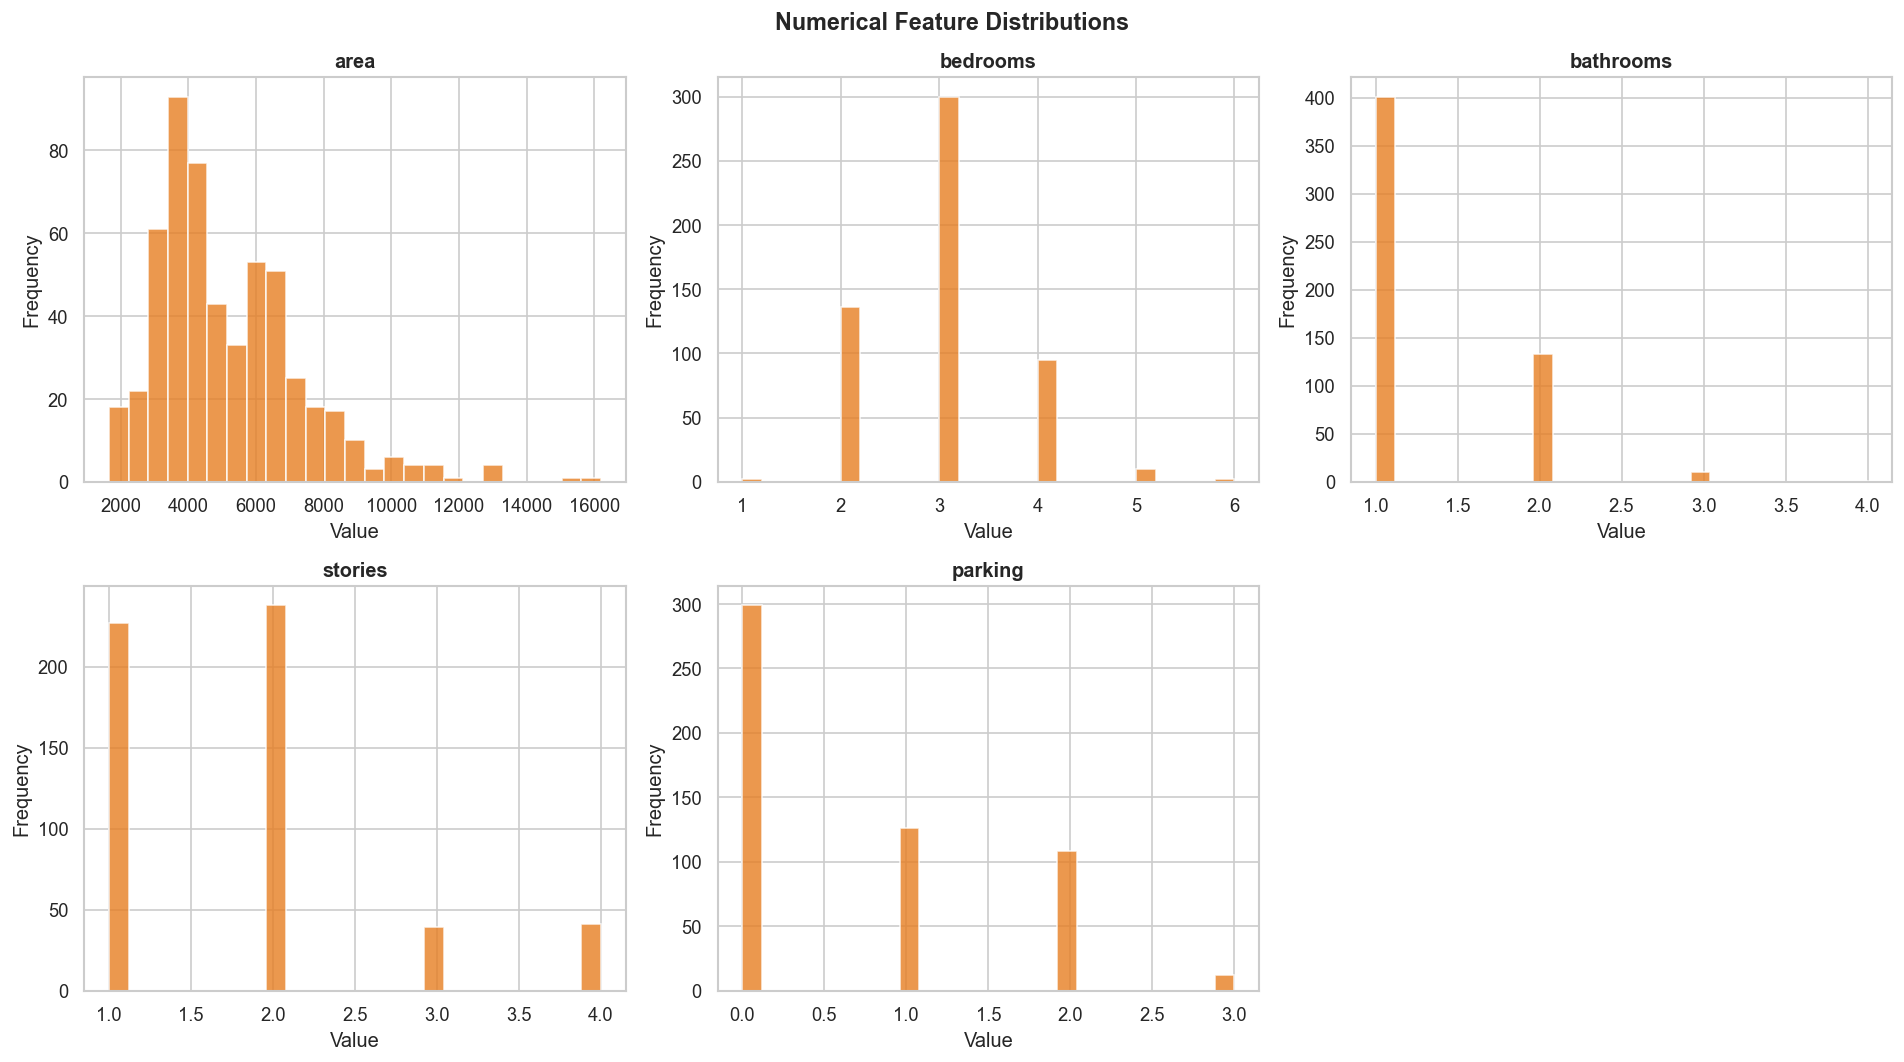

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'price']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols[:6]):
    axes[i].hist(df[col], bins=25, color='#e67e22', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(len(num_cols[:6]), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hp_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Price vs Key Numerical Features (Scatter Plots)


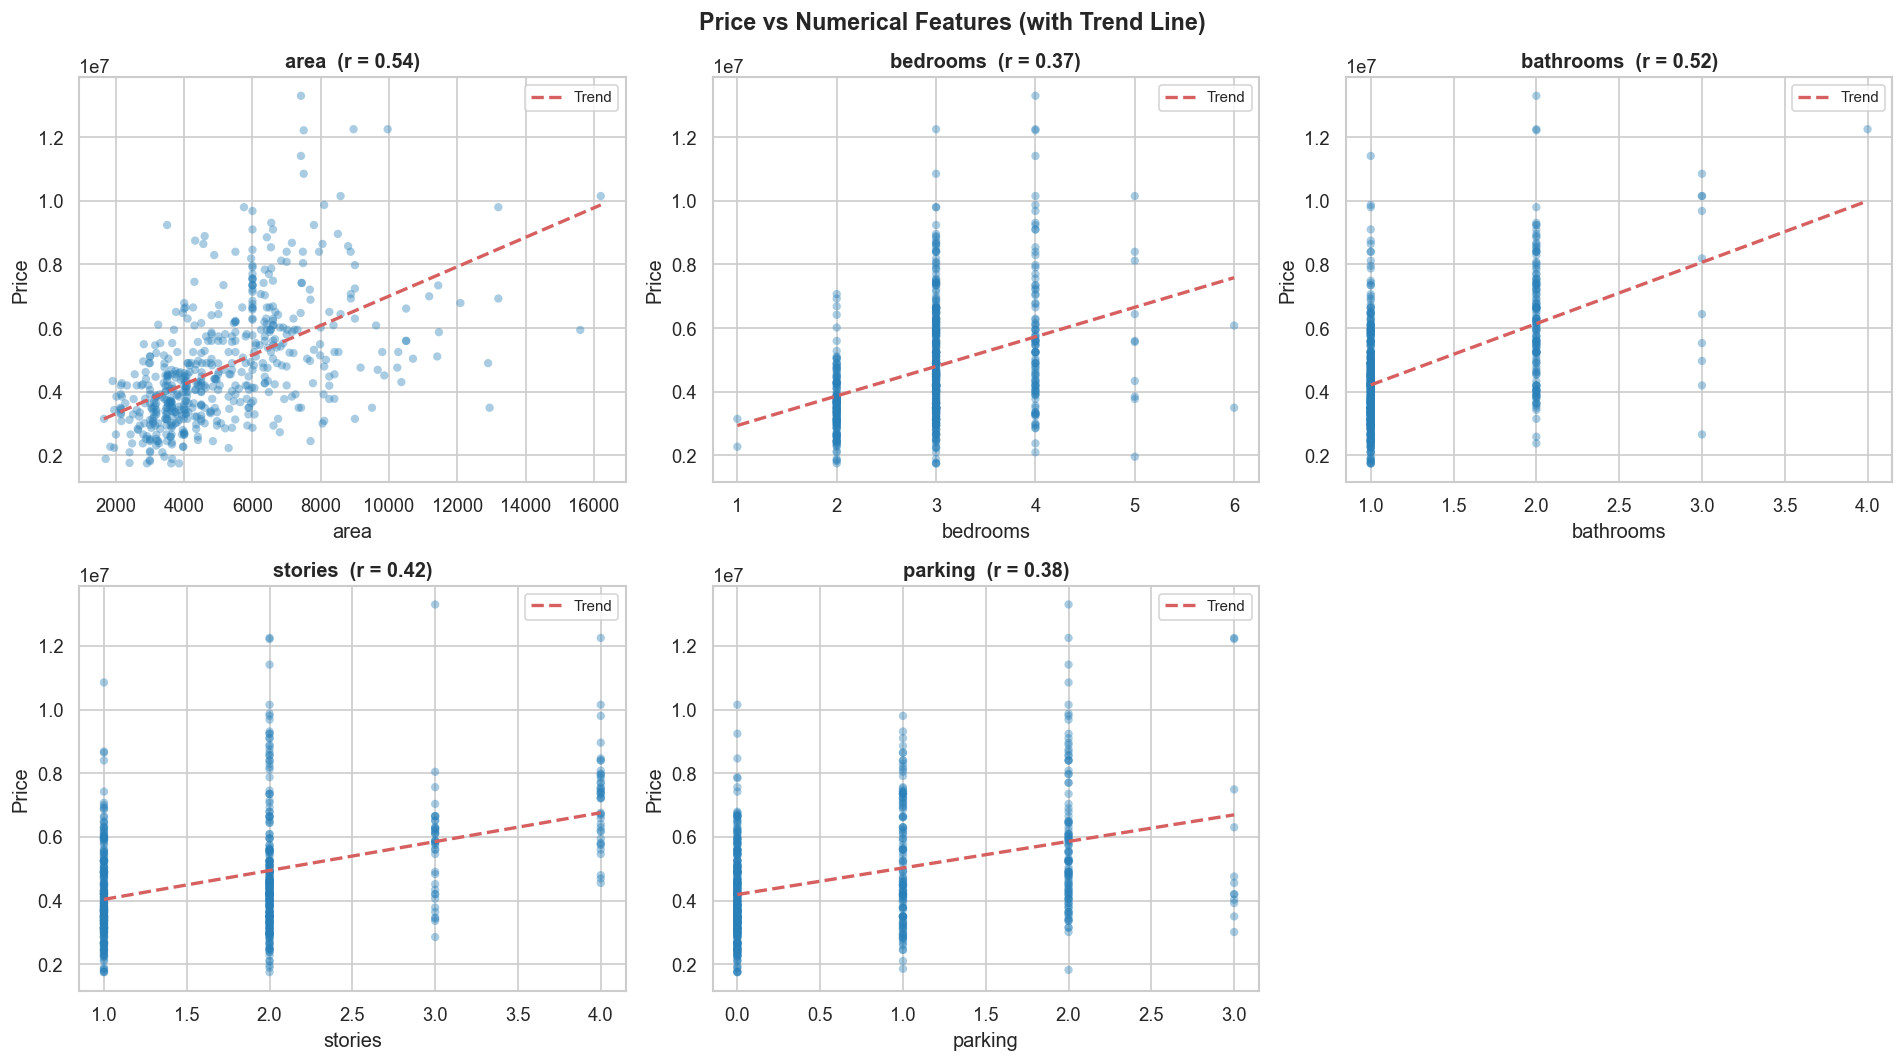

In [8]:
num_features = [c for c in df.select_dtypes(include=np.number).columns if c != 'price']

cols_to_plot = num_features[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    ax.scatter(df[col], df['price'], alpha=0.4, color='#2980b9', edgecolors='none', s=25)

    # Trend line
    z = np.polyfit(df[col], df['price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', lw=2, label='Trend')

    corr = df[col].corr(df['price'])
    ax.set_title(f'{col}  (r = {corr:.2f})', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Price')
    ax.legend(fontsize=9)

for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Price vs Numerical Features (with Trend Line)', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hp_03_price_vs_features.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Categorical Features vs Price (Box Plots)


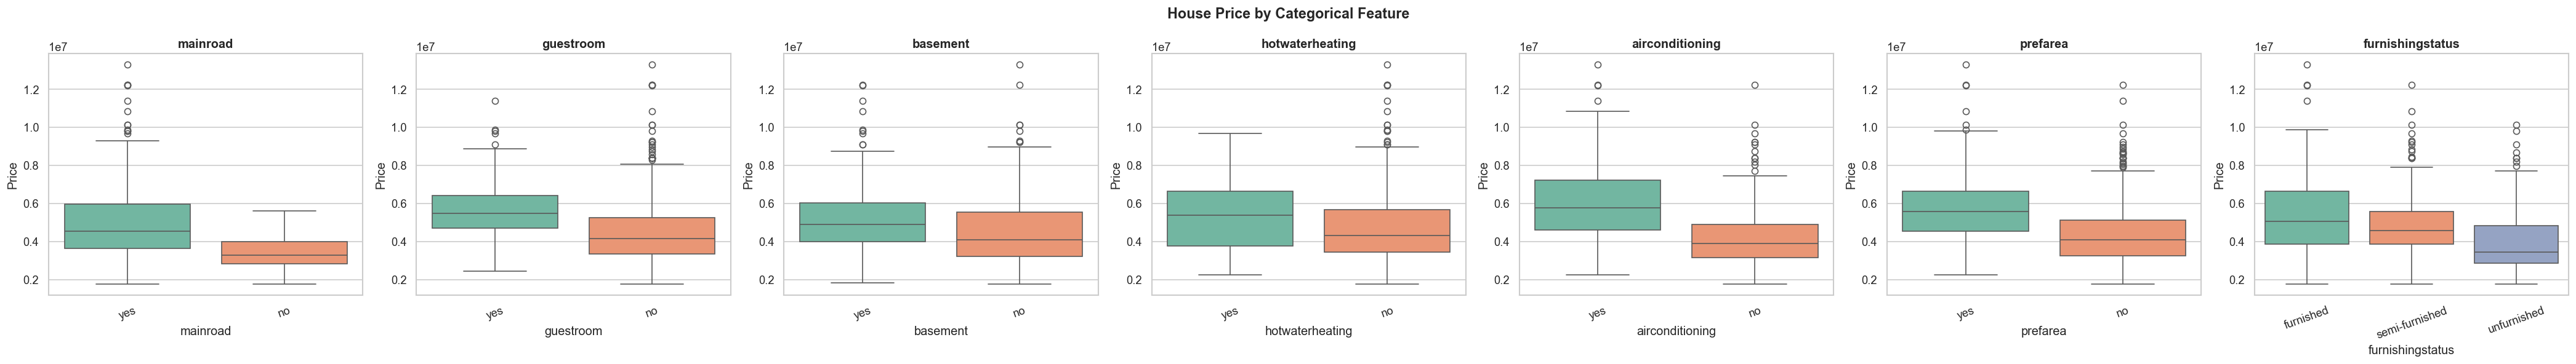

In [9]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

if cat_cols:
    n = len(cat_cols)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1:
        axes = [axes]

    palette = sns.color_palette('Set2', 10)

    for ax, col in zip(axes, cat_cols):
        order = df.groupby(col)['price'].median().sort_values(ascending=False).index
        sns.boxplot(data=df, x=col, y='price', ax=ax, order=order, palette='Set2')
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Price')
        ax.tick_params(axis='x', rotation=20)

    plt.suptitle('House Price by Categorical Feature', fontsize=14, fontweight='bold')
    plt.tight_layout()

else:
    print("No categorical columns found.")

plt.savefig('hp_04_categorical_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.6 Correlation Heatmap



Top correlations with price:
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494


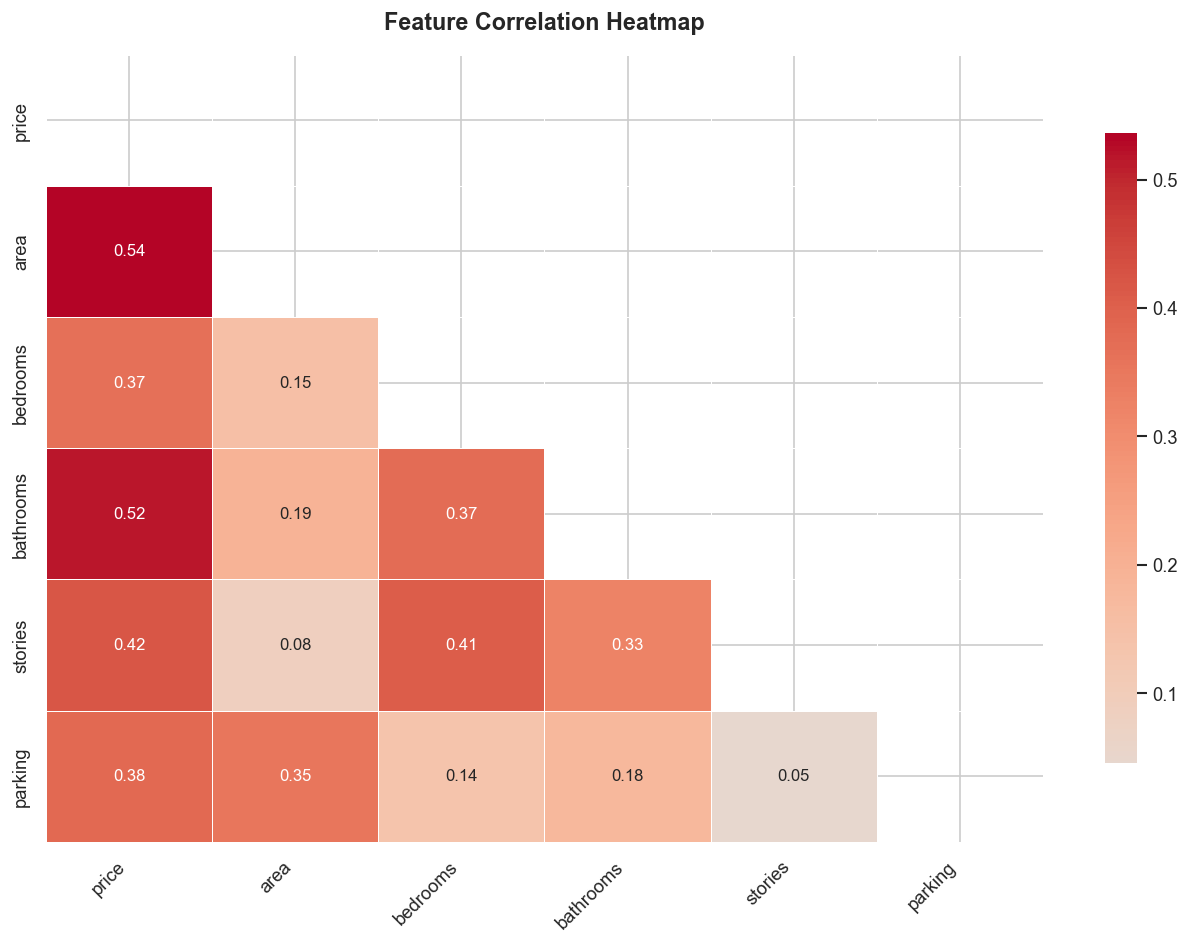

In [10]:
# Only numeric columns for correlation
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(11, 8))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

print("\nTop correlations with price:")
print(corr['price'].drop('price').abs().sort_values(ascending=False).to_string())

plt.savefig('hp_05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.7 Outlier Analysis


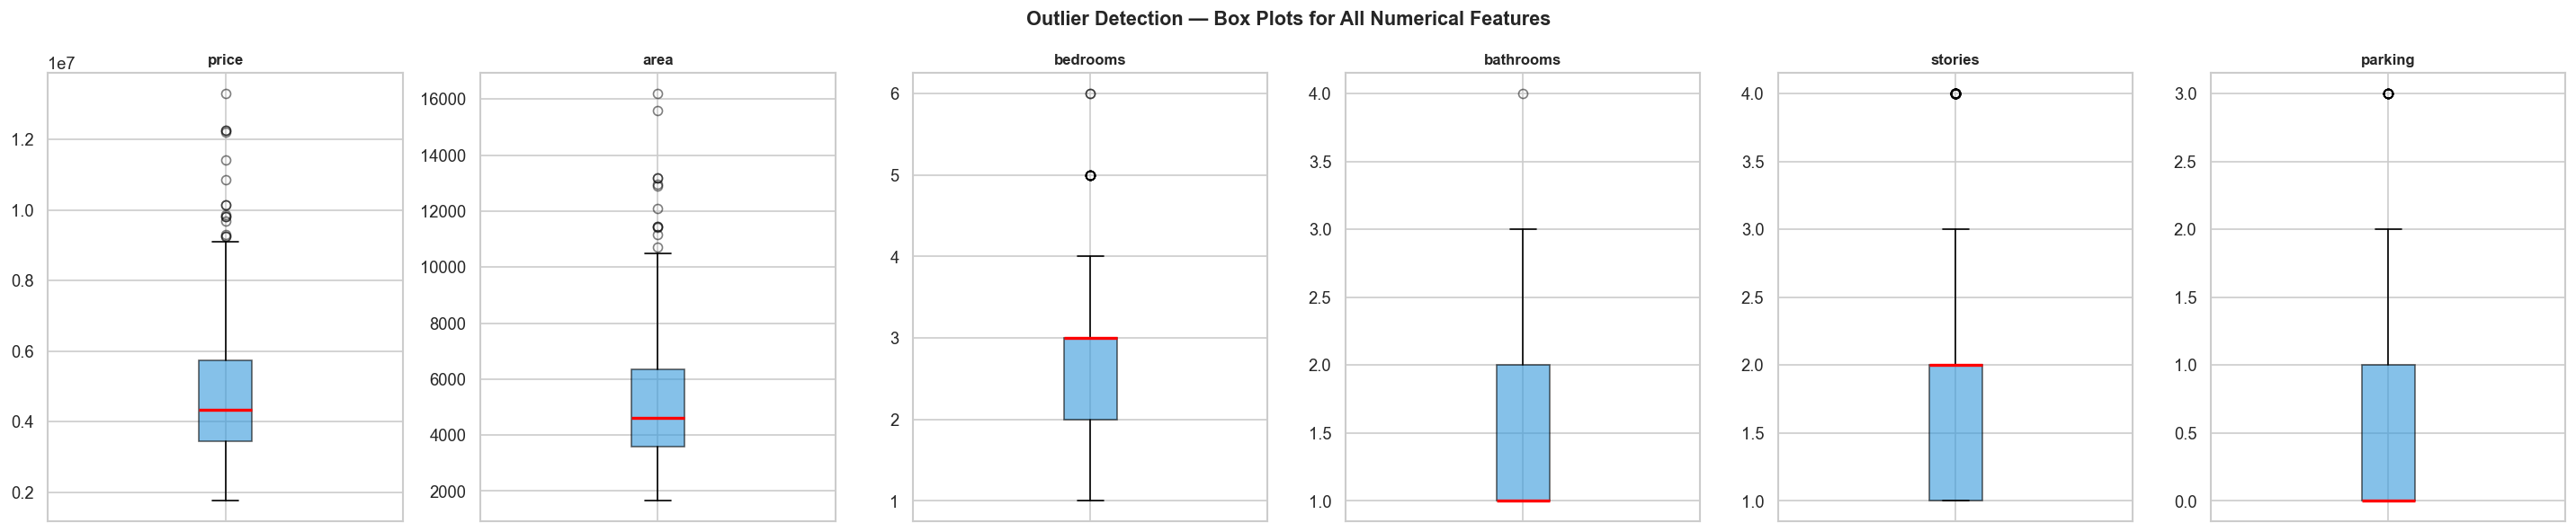

In [11]:
num_cols_out = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(1, len(num_cols_out), figsize=(4*len(num_cols_out), 5))
if len(num_cols_out) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols_out):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               medianprops=dict(color='red', lw=2),
               flierprops=dict(marker='o', color='#e74c3c', alpha=0.5))
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.tick_params(axis='x', labelbottom=False)

plt.suptitle('Outlier Detection — Box Plots for All Numerical Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig('hp_06_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Data Preprocessing

Steps:
1. Encode categorical (yes/no → 1/0, furnishingstatus → ordinal)
2. Show before vs after for categorical encoding
3. Train/test split
4. Feature scaling - show before vs after


### 4.1 Before Preprocessing - Raw Data Sample

In [12]:
print("=== RAW DATA (first 5 rows) ===")
print(df.head().to_string())
print(f"\nData types:")
print(df.dtypes.to_string())


=== RAW DATA (first 5 rows) ===
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement hotwaterheating airconditioning  parking prefarea furnishingstatus
0  13300000  7420         4          2        3      yes        no       no              no             yes        2      yes        furnished
1  12250000  8960         4          4        4      yes        no       no              no             yes        3       no        furnished
2  12250000  9960         3          2        2      yes        no      yes              no              no        2      yes   semi-furnished
3  12215000  7500         4          2        2      yes        no      yes              no             yes        3      yes        furnished
4  11410000  7420         4          1        2      yes       yes      yes              no             yes        2       no        furnished

Data types:
price                int64
area                 int64
bedrooms             int64
bathrooms       

### 4.2 Encode Categorical Features

In [13]:
df_processed = df.copy()

# Binary yes/no columns → 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']
binary_cols = [c for c in binary_cols if c in df_processed.columns]

for col in binary_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

# Furnishing status → ordinal (unfurnished=0, semi-furnished=1, furnished=2)
if 'furnishingstatus' in df_processed.columns:
    furnish_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
    df_processed['furnishingstatus'] = df_processed['furnishingstatus'].map(furnish_map)

print("=== AFTER Encoding (first 5 rows) ===")
print(df_processed.head().to_string())
print(f"\nData types after encoding:")
print(df_processed.dtypes.to_string())


=== AFTER Encoding (first 5 rows) ===
      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  hotwaterheating  airconditioning  parking  prefarea  furnishingstatus
0  13300000  7420         4          2        3         1          0         0                0                1        2         1                 2
1  12250000  8960         4          4        4         1          0         0                0                1        3         0                 2
2  12250000  9960         3          2        2         1          0         1                0                0        2         1                 1
3  12215000  7500         4          2        2         1          0         1                0                1        3         1                 2
4  11410000  7420         4          1        2         1          1         1                0                1        2         0                 2

Data types after encoding:
price               int64
area    

### 4.3 Before vs After Encoding - Visual

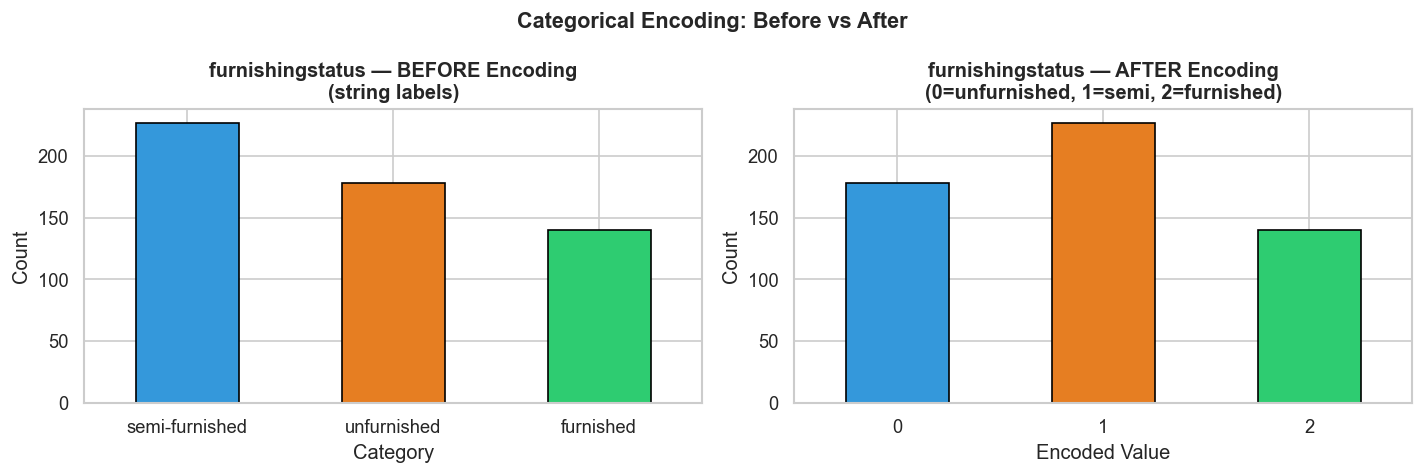

In [14]:
if 'furnishingstatus' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Before: categorical bar
    df['furnishingstatus'].value_counts().plot(kind='bar', ax=axes[0],
        color=['#3498db','#e67e22','#2ecc71'], edgecolor='black', width=0.5)
    axes[0].set_title('furnishingstatus — BEFORE Encoding\n(string labels)', fontweight='bold')
    axes[0].set_xlabel('Category')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=0)

    # After: numeric bar
    df_processed['furnishingstatus'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
        color=['#3498db','#e67e22','#2ecc71'], edgecolor='black', width=0.5)
    axes[1].set_title('furnishingstatus — AFTER Encoding\n(0=unfurnished, 1=semi, 2=furnished)',
                      fontweight='bold')
    axes[1].set_xlabel('Encoded Value')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=0)

    plt.suptitle('Categorical Encoding: Before vs After', fontsize=13, fontweight='bold')
    plt.tight_layout()

    plt.savefig('hp_07_encoding_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()
    

### 4.4 Train/Test Split

In [15]:
X = df_processed.drop(columns=['price'])
y = df_processed['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Features     : {list(X.columns)}")
print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")


Features     : ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']
Training set : 436 samples
Test set     : 109 samples


### 4.5 Feature Scaling - Before vs After

In [16]:
# Before scaling stats
print("=== RAW Feature Statistics (Before Scaling) ===\n")
raw_stats = X_train.describe().loc[['mean', 'std', 'min', 'max']].T
raw_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max']
print(raw_stats.round(2).to_string())


=== RAW Feature Statistics (Before Scaling) ===

                     Mean  Std Dev     Min      Max
area              5154.14  2204.31  1650.0  16200.0
bedrooms             2.96     0.75     1.0      6.0
bathrooms            1.27     0.48     1.0      4.0
stories              1.78     0.86     1.0      4.0
mainroad             0.86     0.35     0.0      1.0
guestroom            0.18     0.38     0.0      1.0
basement             0.36     0.48     0.0      1.0
hotwaterheating      0.05     0.22     0.0      1.0
airconditioning      0.31     0.46     0.0      1.0
parking              0.69     0.85     0.0      3.0
prefarea             0.23     0.42     0.0      1.0
furnishingstatus     0.94     0.75     0.0      2.0


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("=== SCALED Feature Statistics (After Scaling) ===\n")
scaled_stats = X_train_scaled_df.describe().loc[['mean', 'std', 'min', 'max']].T
scaled_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max']
print(scaled_stats.round(4).to_string())
print("\nAll features now have mean ≈ 0 and std ≈ 1")


=== SCALED Feature Statistics (After Scaling) ===

                  Mean  Std Dev     Min     Max
area               0.0   1.0011 -1.5915  5.0168
bedrooms           0.0   1.0011 -2.6223  4.0716
bathrooms          0.0   1.0011 -0.5580  5.7334
stories            0.0   1.0011 -0.9125  2.5876
mainroad           0.0   1.0011 -2.4561  0.4072
guestroom          0.0   1.0011 -0.4668  2.1424
basement          -0.0   1.0011 -0.7464  1.3397
hotwaterheating   -0.0   1.0011 -0.2305  4.3380
airconditioning    0.0   1.0011 -0.6661  1.5012
parking           -0.0   1.0011 -0.8031  2.7100
prefarea          -0.0   1.0011 -0.5526  1.8096
furnishingstatus   0.0   1.0011 -1.2508  1.4094

All features now have mean ≈ 0 and std ≈ 1


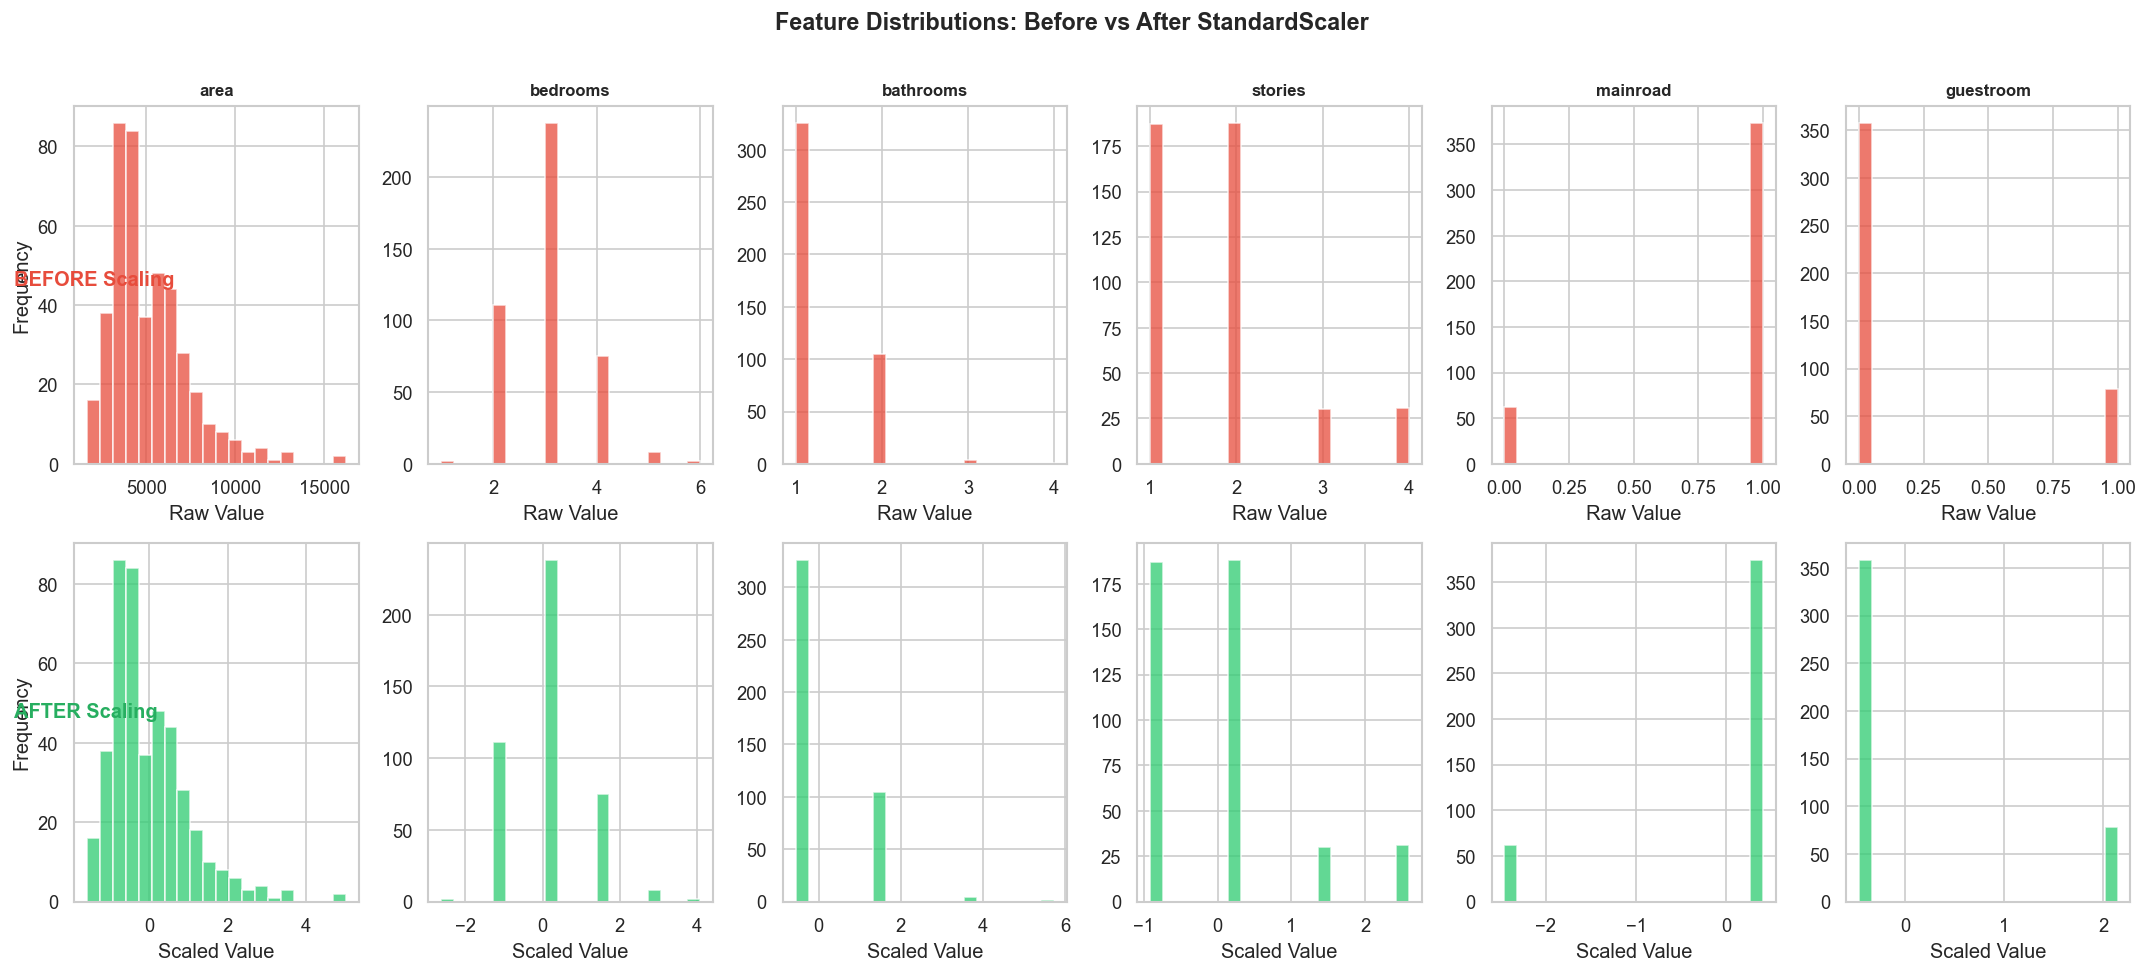

In [19]:
# Visual: mean ± std before vs after for numeric features
num_feat = X.select_dtypes(include=np.number).columns.tolist()[:6]

fig, axes = plt.subplots(2, len(num_feat), figsize=(18, 8))

for i, col in enumerate(num_feat):
    # Before
    axes[0, i].hist(X_train[col], bins=20, color='#e74c3c', alpha=0.75, edgecolor='white')
    axes[0, i].set_title(col, fontweight='bold', fontsize=10)
    axes[0, i].set_xlabel('Raw Value')
    if i == 0:
        axes[0, i].set_ylabel('Frequency')

    # After
    axes[1, i].hist(X_train_scaled_df[col], bins=20, color='#2ecc71', alpha=0.75, edgecolor='white')
    axes[1, i].set_xlabel('Scaled Value')
    if i == 0:
        axes[1, i].set_ylabel('Frequency')

# Row labels
fig.text(0.01, 0.73, 'BEFORE Scaling', va='center', ha='left',
         fontsize=12, fontweight='bold', color='#e74c3c')
fig.text(0.01, 0.28, 'AFTER Scaling', va='center', ha='left',
         fontsize=12, fontweight='bold', color='#27ae60')

plt.suptitle('Feature Distributions: Before vs After StandardScaler',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

plt.savefig('hp_08_scaling_before_after.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Model Training

Train two regression models:

1. **Linear Regression** - Fits a straight-line relationship between features and price. Simple, interpretable baseline.
2. **Gradient Boosting Regressor** - Builds many weak decision trees sequentially, each correcting the previous one's errors. Handles non-linearity and interactions very well.


### 5.1 Linear Regression

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Linear Regression ===")
print(f"MAE  : {mae_lr:,.0f}")
print(f"RMSE : {rmse_lr:,.0f}")
print(f"R²   : {r2_lr:.4f}  ({r2_lr*100:.1f}% variance explained)")


=== Linear Regression ===
MAE  : 979,680
RMSE : 1,331,071
R²   : 0.6495  (64.9% variance explained)


### 5.2 Gradient Boosting Regressor

In [21]:
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                      max_depth=4, random_state=42)
gb_model.fit(X_train, y_train)   # Gradient Boosting doesn't require scaling

y_pred_gb = gb_model.predict(X_test)

mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb   = r2_score(y_test, y_pred_gb)

print("=== Gradient Boosting ===")
print(f"MAE  : {mae_gb:,.0f}")
print(f"RMSE : {rmse_gb:,.0f}")
print(f"R²   : {r2_gb:.4f}  ({r2_gb*100:.1f}% variance explained)")


=== Gradient Boosting ===
MAE  : 1,007,535
RMSE : 1,341,598
R²   : 0.6439  (64.4% variance explained)


---
## 6. Model Evaluation

### 6.1 Actual vs Predicted Price Plots

A perfect model would have all points on the diagonal red line (predicted = actual).


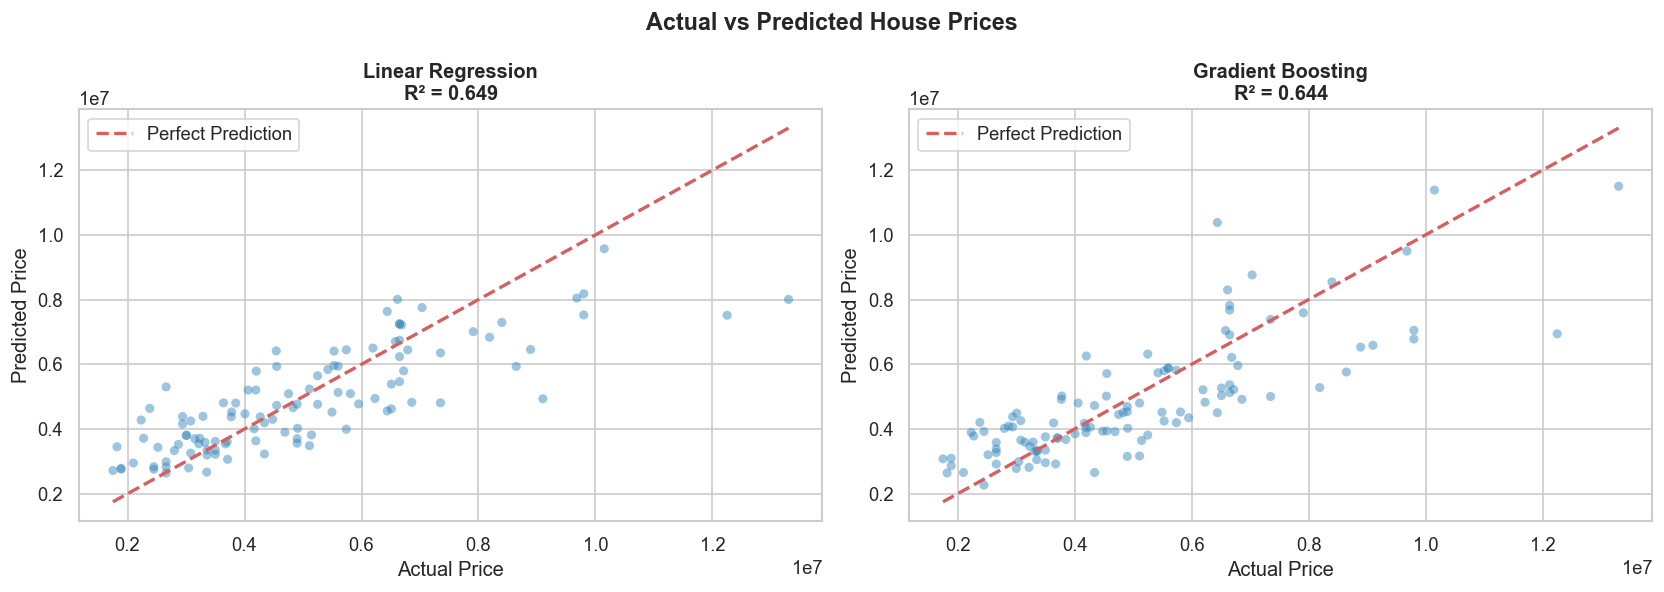

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [('Linear Regression', y_pred_lr),
                                       ('Gradient Boosting', y_pred_gb)]):
    ax.scatter(y_test, y_pred, alpha=0.45, color='#2980b9', edgecolors='none', s=30)

    # Perfect prediction line
    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')

    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{name}\nR² = {r2:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.legend()

plt.suptitle('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hp_09_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Residual Plots

Residuals = Actual - Predicted. A good model has residuals randomly scattered around 0 with no pattern.


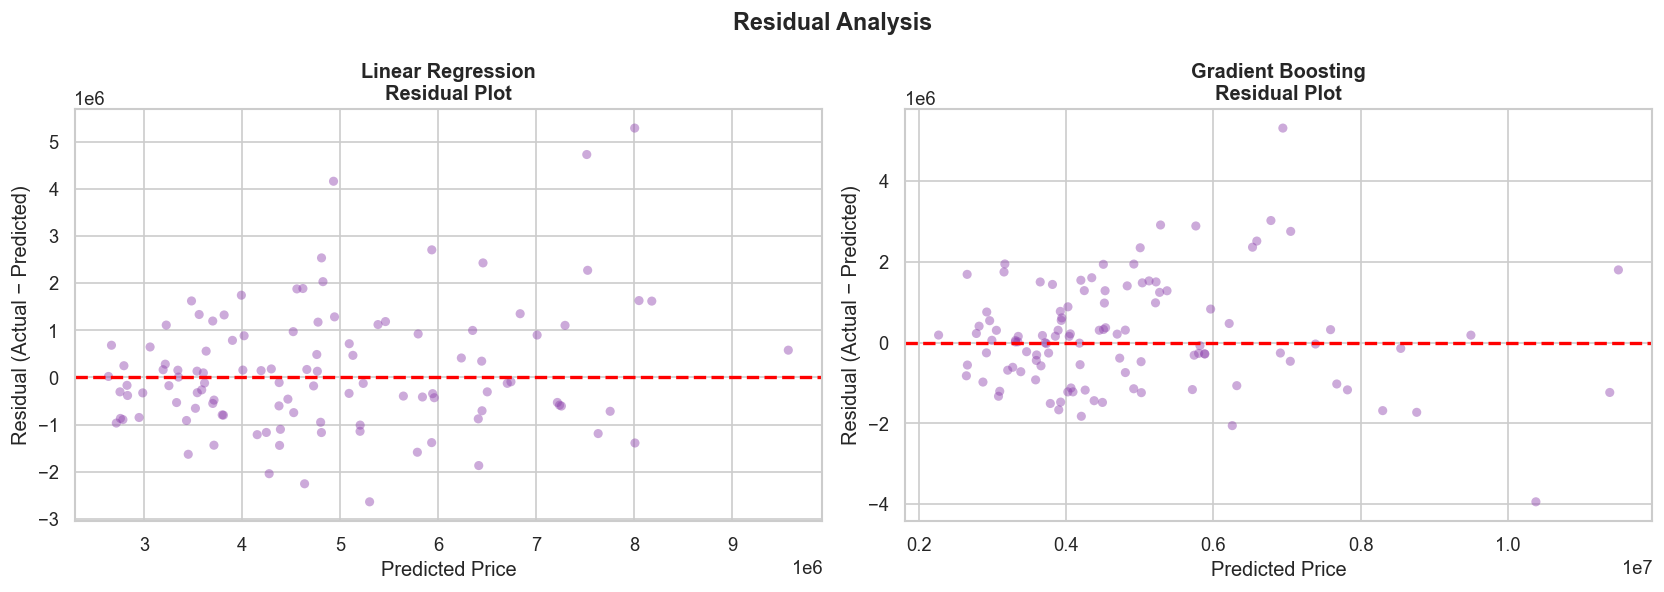

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [('Linear Regression', y_pred_lr),
                                       ('Gradient Boosting', y_pred_gb)]):
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.45, color='#8e44ad', edgecolors='none', s=30)
    ax.axhline(0, color='red', linestyle='--', lw=2)
    ax.set_title(f'{name}\nResidual Plot', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Price')
    ax.set_ylabel('Residual (Actual − Predicted)')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hp_10_residuals.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.3 Residual Distribution


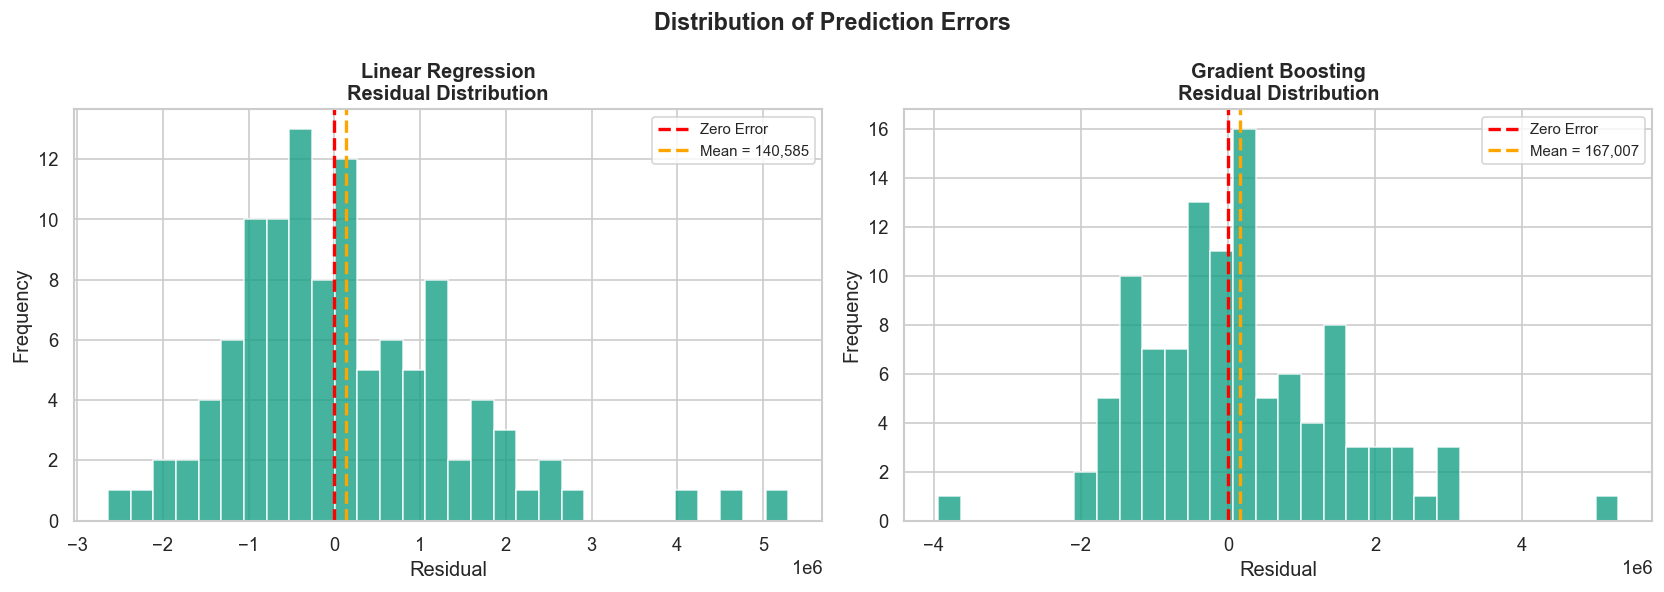

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(axes, [('Linear Regression', y_pred_lr),
                                       ('Gradient Boosting', y_pred_gb)]):
    residuals = y_test.values - y_pred
    ax.hist(residuals, bins=30, color='#16a085', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', lw=2, linestyle='--', label='Zero Error')
    ax.axvline(residuals.mean(), color='orange', lw=2, linestyle='--',
               label=f'Mean = {residuals.mean():,.0f}')
    ax.set_title(f'{name}\nResidual Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Residual')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hp_11_residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.4 Model Comparison - MAE, RMSE, R²


In [25]:
metrics_df = pd.DataFrame({
    'Model' : ['Linear Regression', 'Gradient Boosting'],
    'MAE'   : [mae_lr, mae_gb],
    'RMSE'  : [rmse_lr, rmse_gb],
    'R²'    : [r2_lr, r2_gb]
})

print("=" * 58)
print("             MODEL PERFORMANCE SUMMARY")
print("=" * 58)
print(f"{'Model':<25} {'MAE':>10} {'RMSE':>12} {'R²':>8}")
print("-" * 58)
for _, row in metrics_df.iterrows():
    print(f"{row['Model']:<25} {row['MAE']:>10,.0f} {row['RMSE']:>12,.0f} {row['R²']:>8.4f}")
print("=" * 58)

best = metrics_df.loc[metrics_df['R²'].idxmax(), 'Model']
print(f"\nBest Model by R²: {best}")


             MODEL PERFORMANCE SUMMARY
Model                            MAE         RMSE       R²
----------------------------------------------------------
Linear Regression            979,680    1,331,071   0.6495
Gradient Boosting          1,007,535    1,341,598   0.6439

Best Model by R²: Linear Regression


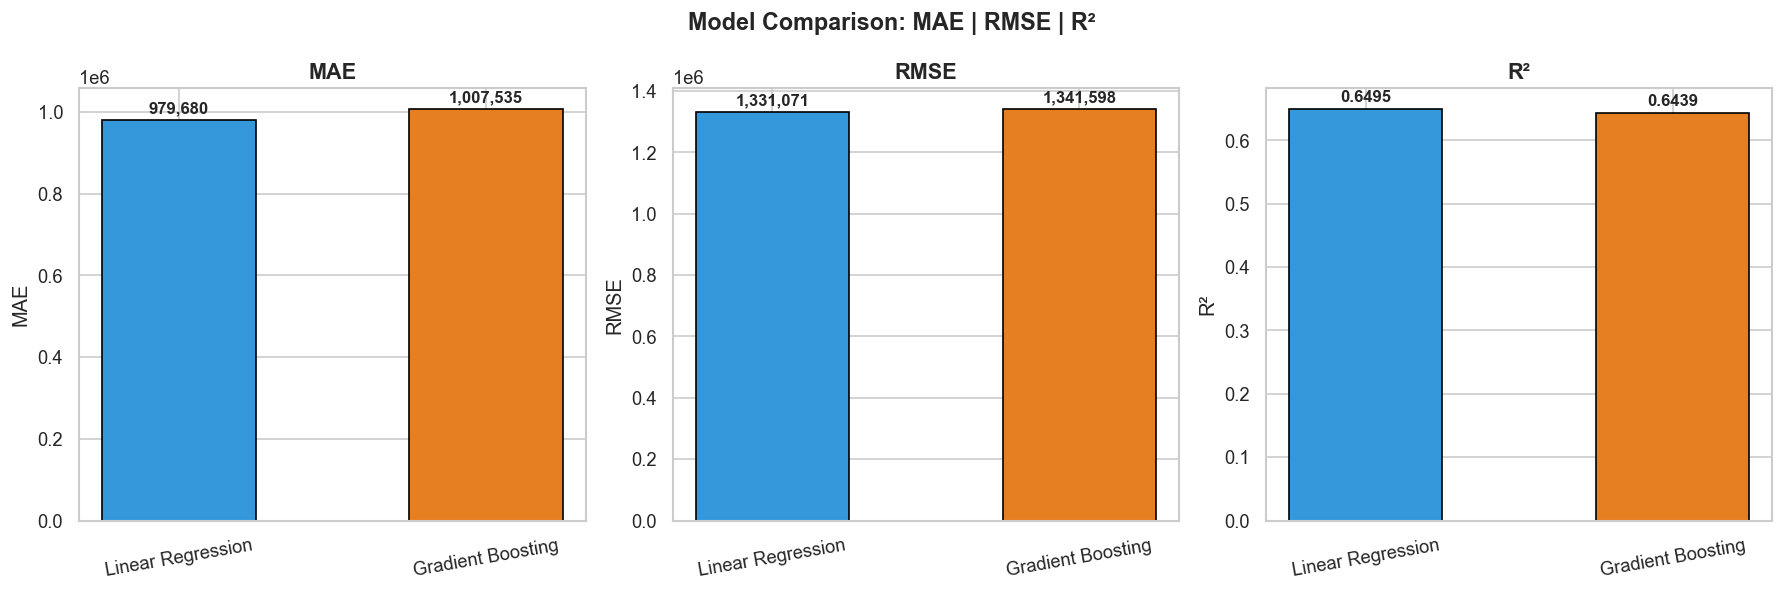

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models = ['Linear Regression', 'Gradient Boosting']
colors = ['#3498db', '#e67e22']

for ax, (metric, vals) in zip(axes, [
    ('MAE',  [mae_lr, mae_gb]),
    ('RMSE', [rmse_lr, rmse_gb]),
    ('R²',   [r2_lr, r2_gb])
]):
    bars = ax.bar(models, vals, color=colors, edgecolor='black', width=0.5)
    for bar in bars:
        h = bar.get_height()
        label = f'{h:.4f}' if metric == 'R²' else f'{h:,.0f}'
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.01, label,
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Model Comparison: MAE | RMSE | R²', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hp_12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Saving the Trained Models

In [39]:
import joblib

# Save both models and the scaler
joblib.dump(lr_model, 'house_price_lr_model_BEST.pkl')
joblib.dump(gb_model, 'house_price_gb_model.pkl')
joblib.dump(scaler,   'house_price_scaler.pkl')

print("Models and scaler saved:")
print("   house_price_lr_model_BEST.pkl  ← recommended for deployment")
print("   house_price_gb_model.pkl")
print("   house_price_scaler.pkl")

Models and scaler saved:
   house_price_lr_model_BEST.pkl  ← recommended for deployment
   house_price_gb_model.pkl
   house_price_scaler.pkl


---
## 8. Feature Importance Analysis


### 8.1 Linear Regression - Coefficient Plot

Positive coefficients (price drivers):
bathrooms           523153.382843
area                519288.130105
airconditioning     362446.186466
stories             348177.113610
prefarea            266661.049149
parking             192786.985891
basement            188462.048566
furnishingstatus    158183.270169
hotwaterheating     150570.028279
mainroad            128115.927978
guestroom            89357.646208
bedrooms             58690.918498

Negative coefficients:
Series([], )


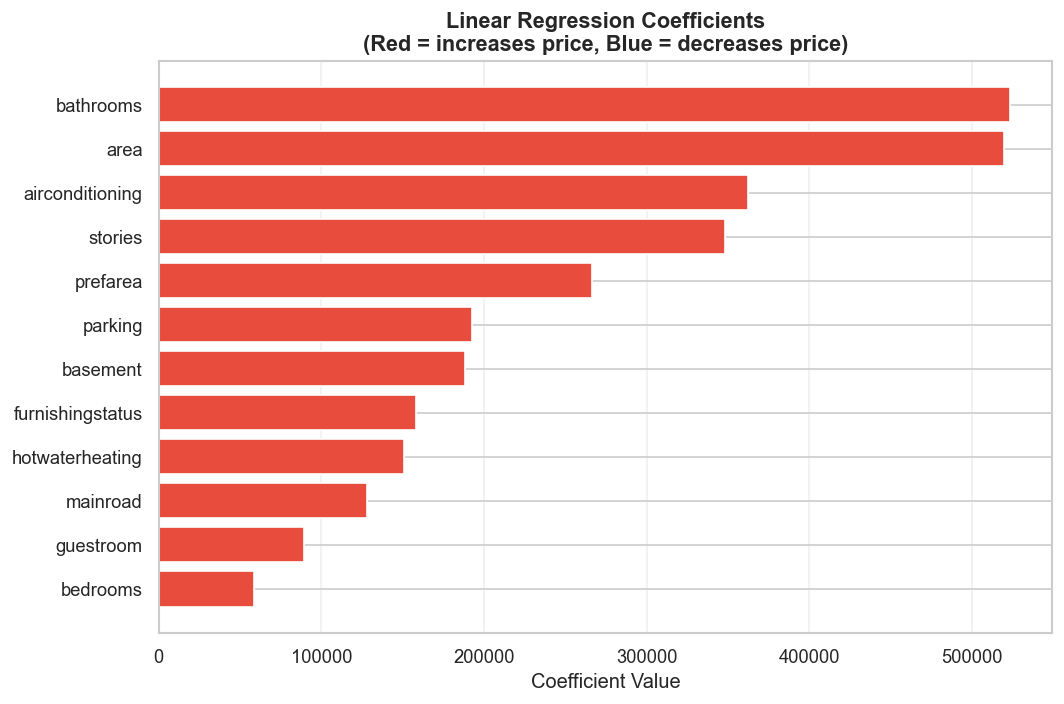

In [27]:
feature_names = X.columns.tolist()
lr_coefs = pd.Series(lr_model.coef_, index=feature_names).sort_values()

colors = ['#e74c3c' if c > 0 else '#3498db' for c in lr_coefs]

plt.figure(figsize=(9, 6))
plt.barh(lr_coefs.index, lr_coefs.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', lw=1)
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Linear Regression Coefficients\n(Red = increases price, Blue = decreases price)',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

print("Positive coefficients (price drivers):")
print(lr_coefs[lr_coefs > 0].sort_values(ascending=False).to_string())
print("\nNegative coefficients:")
print(lr_coefs[lr_coefs < 0].sort_values().to_string())

plt.savefig('hp_13_lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.2 Gradient Boosting - Feature Importance

Top 5 most important features:
area               0.471810
bathrooms          0.167042
airconditioning    0.070129
stories            0.058283
bedrooms           0.048709


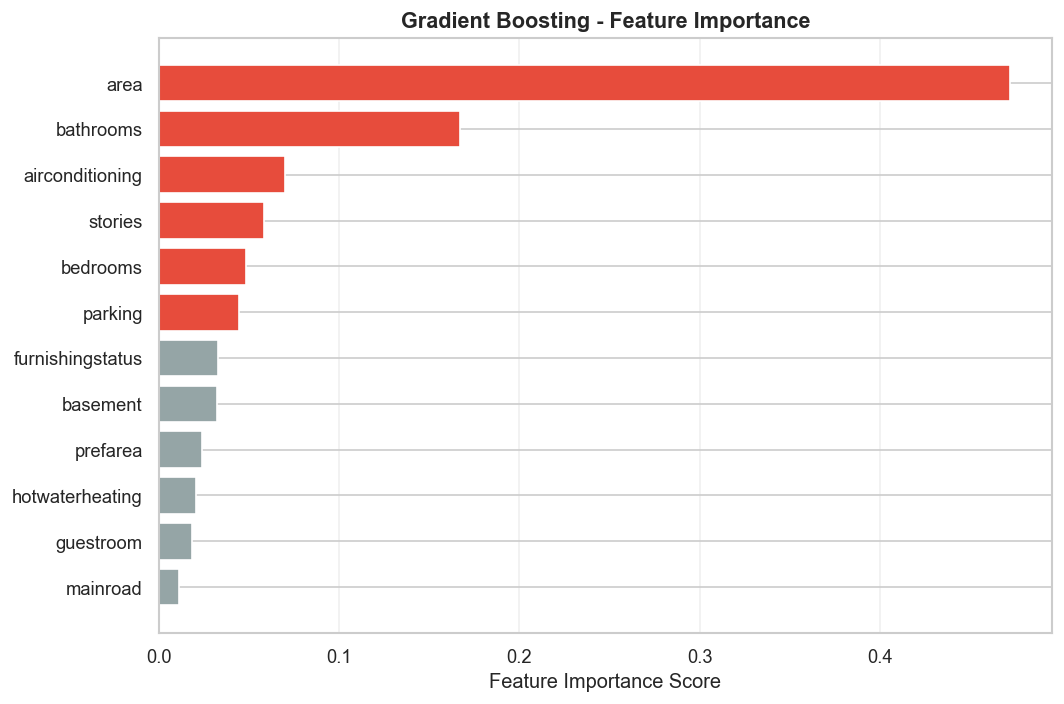

In [44]:
gb_importance = pd.Series(gb_model.feature_importances_,
                          index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#e74c3c' if v > gb_importance.median() else '#95a5a6' for v in gb_importance]
plt.barh(gb_importance.index, gb_importance.values, color=colors, edgecolor='white')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Gradient Boosting - Feature Importance', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

print("Top 5 most important features:")
print(gb_importance.sort_values(ascending=False).head(5).to_string())

plt.savefig('hp_14_gb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Making Predictions

### 9.1 Predictions on the Test Set


In [29]:
results_df = X_test.copy().reset_index(drop=True)
results_df['Actual_Price']    = y_test.values
results_df['LR_Predicted']    = y_pred_lr.round(0)
results_df['GB_Predicted']    = y_pred_gb.round(0)
results_df['LR_Error']        = (results_df['Actual_Price'] - results_df['LR_Predicted']).abs()
results_df['GB_Error']        = (results_df['Actual_Price'] - results_df['GB_Predicted']).abs()
results_df['LR_Error_%']      = (results_df['LR_Error'] / results_df['Actual_Price'] * 100).round(1)
results_df['GB_Error_%']      = (results_df['GB_Error'] / results_df['Actual_Price'] * 100).round(1)

print("Sample Predictions (first 10 houses):")
display_cols = ['Actual_Price', 'LR_Predicted', 'LR_Error_%', 'GB_Predicted', 'GB_Error_%']
print(results_df[display_cols].head(10).to_string())


Sample Predictions (first 10 houses):
   Actual_Price  LR_Predicted  LR_Error_%  GB_Predicted  GB_Error_%
0       4060000     5203692.0        28.2     4802953.0        18.3
1       6650000     7257004.0         9.1     7675435.0        15.4
2       3710000     3062829.0        17.4     3713353.0         0.1
3       6440000     4559592.0        29.2     4504042.0        30.1
4       2800000     3332932.0        19.0     4020965.0        43.6
5       4900000     3563081.0        27.3     3154041.0        35.6
6       5250000     5645466.0         7.5     6316738.0        20.3
7       4543000     6413980.0        41.2     5016516.0        10.4
8       2450000     2755832.0        12.5     3923493.0        60.1
9       3353000     2668939.0        20.4     3050359.0         9.0


### 9.2 Predicted vs Actual - Line Chart (Sorted by Price)

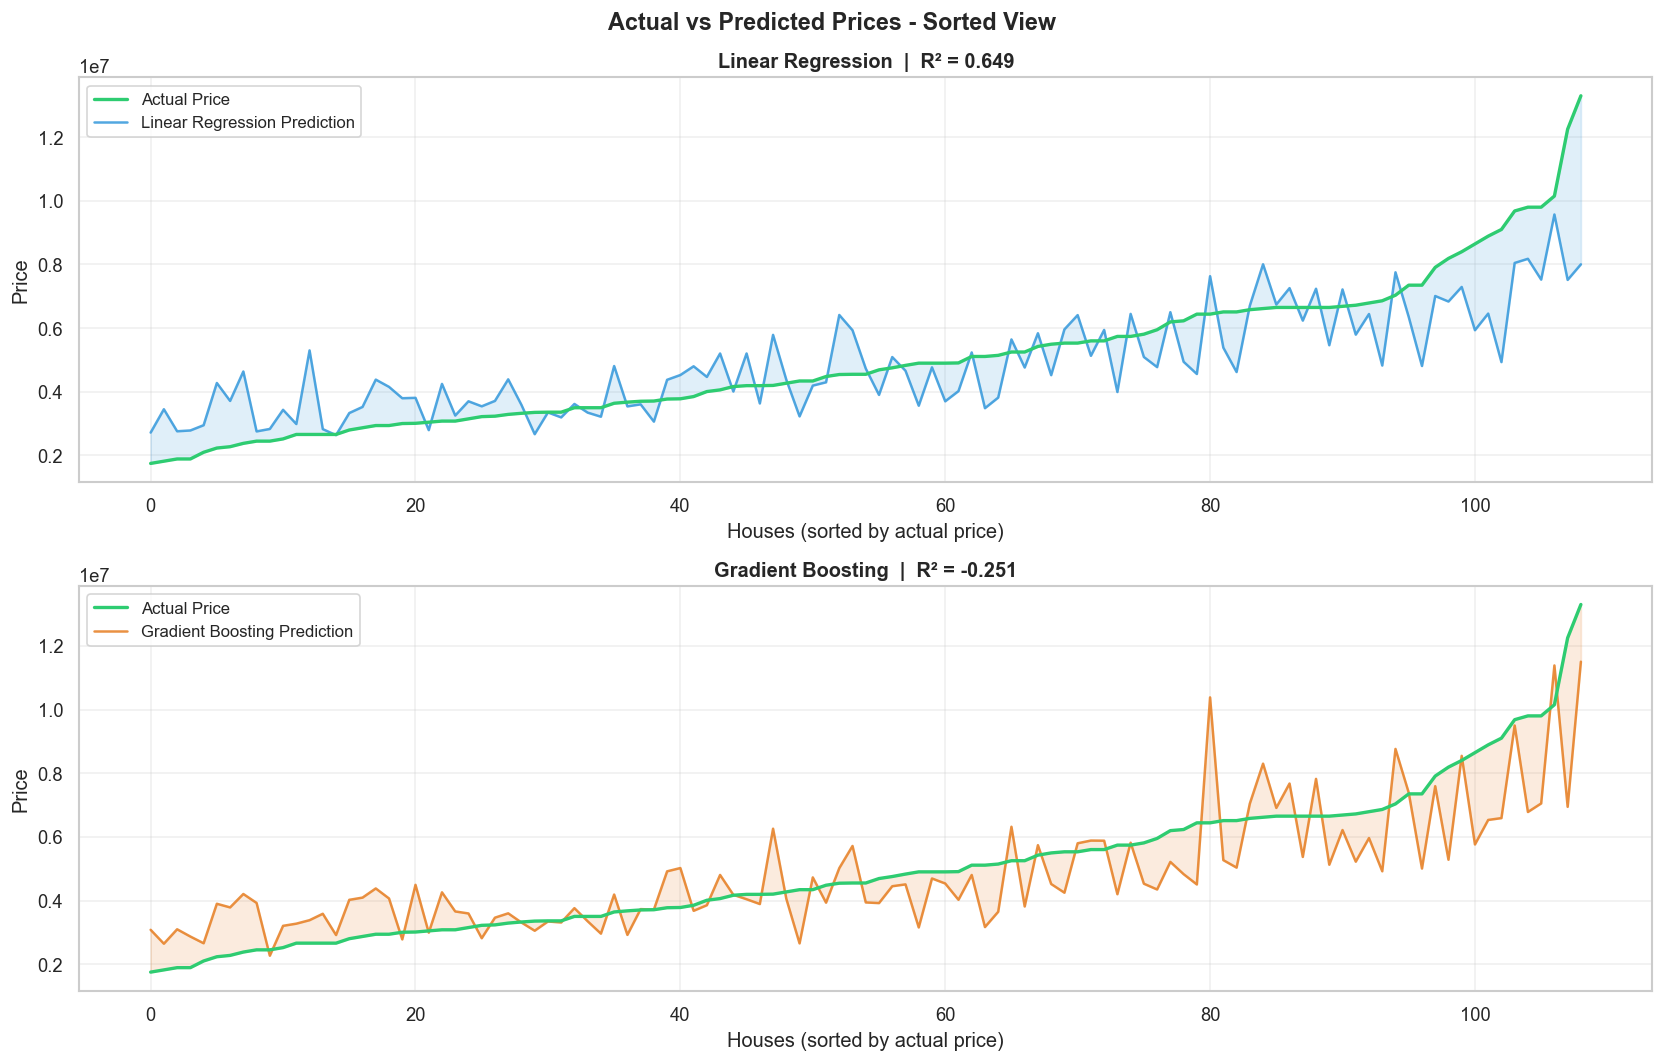

In [43]:
# Sort by actual price for a cleaner visualization
sorted_idx = np.argsort(y_test.values)
actual_sorted  = y_test.values[sorted_idx]
lr_sorted      = y_pred_lr[sorted_idx]
gb_sorted      = y_pred_gb[sorted_idx]
x_axis         = np.arange(len(actual_sorted))

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, (name, preds, color) in zip(axes, [
    ('Linear Regression', lr_sorted, '#3498db'),
    ('Gradient Boosting', gb_sorted, '#e67e22')
]):
    ax.fill_between(x_axis, actual_sorted, preds, alpha=0.15, color=color)
    ax.plot(x_axis, actual_sorted, color='#2ecc71', lw=2, label='Actual Price', zorder=3)
    ax.plot(x_axis, preds, color=color, lw=1.5, alpha=0.85, label=f'{name} Prediction', zorder=2)
    r2 = r2_score(y_test, preds if name == 'Gradient Boosting' else y_pred_lr)
    ax.set_title(f'{name}  |  R² = {r2:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Houses (sorted by actual price)')
    ax.set_ylabel('Price')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs Predicted Prices - Sorted View', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hp_15_sorted_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.3 Prediction Error Distribution

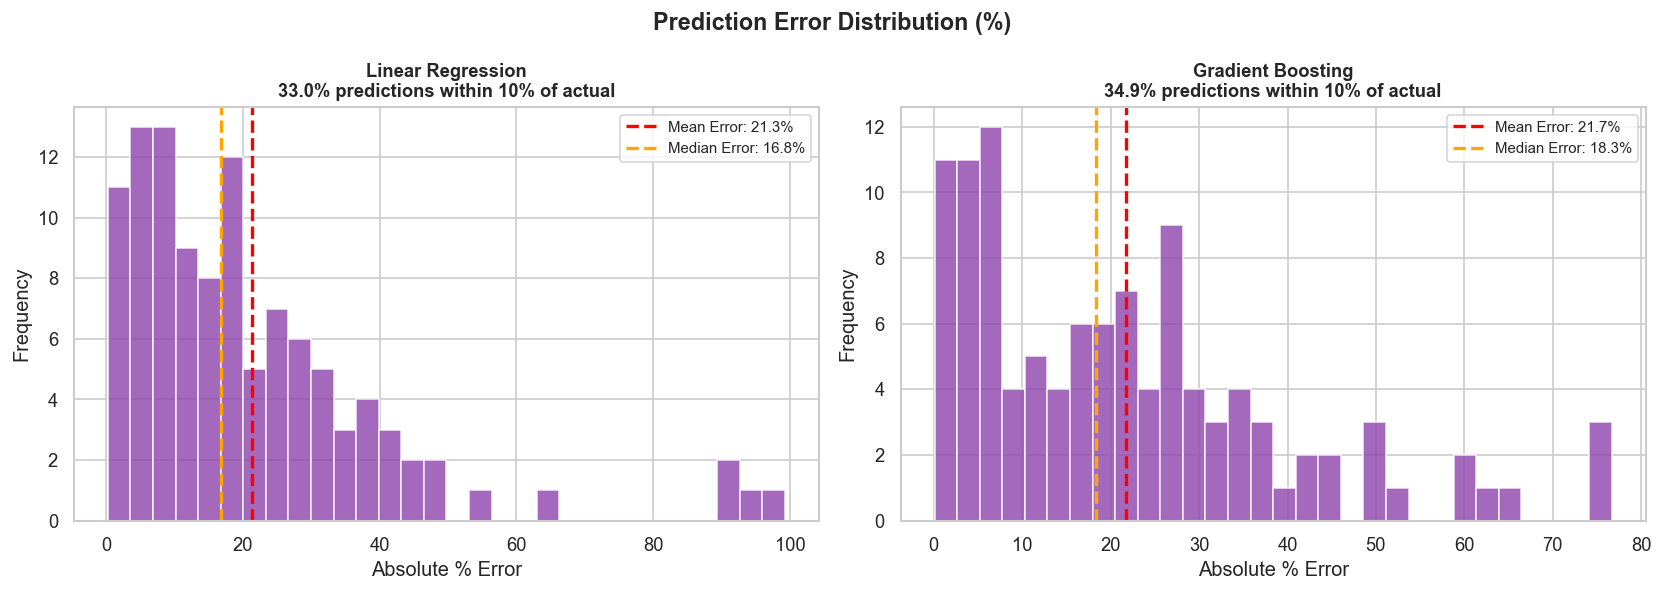

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, preds) in zip(axes, [('Linear Regression', y_pred_lr),
                                      ('Gradient Boosting', y_pred_gb)]):
    pct_errors = np.abs(y_test.values - preds) / y_test.values * 100

    ax.hist(pct_errors, bins=30, color='#8e44ad', edgecolor='white', alpha=0.8)
    ax.axvline(pct_errors.mean(), color='red', lw=2, linestyle='--',
               label=f'Mean Error: {pct_errors.mean():.1f}%')
    ax.axvline(np.median(pct_errors), color='orange', lw=2, linestyle='--',
               label=f'Median Error: {np.median(pct_errors):.1f}%')

    within_10 = (pct_errors <= 10).sum() / len(pct_errors) * 100
    ax.set_title(f'{name}\n{within_10:.1f}% predictions within 10% of actual',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Absolute % Error')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)

plt.suptitle('Prediction Error Distribution (%)', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('hp_16_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.4 Predict Price for a Single New House

In [40]:
# ── Define a new house ───────────────────────────────────────────────────────
# Modify these values to test different house profiles
new_house = {
    'area'            : 5000,    # sq ft
    'bedrooms'        : 3,
    'bathrooms'       : 2,
    'stories'         : 2,
    'mainroad'        : 1,       # 1 = yes
    'guestroom'       : 0,
    'basement'        : 1,
    'hotwaterheating' : 0,
    'airconditioning' : 1,
    'parking'         : 2,
    'prefarea'        : 1,
    'furnishingstatus': 2        # 2 = furnished
}

# Keep only features the model was trained on
house_df = pd.DataFrame([{k: new_house[k] for k in X.columns if k in new_house}])

# Predict
house_scaled  = scaler.transform(house_df)
lr_price      = lr_model.predict(house_scaled)[0]
gb_price      = gb_model.predict(house_df)[0]

print("=" * 50)
print("       SINGLE HOUSE PRICE PREDICTION")
print("=" * 50)
for k, v in new_house.items():
    print(f"  {k:<22}: {v}")
print("-" * 50)
print(f"  Linear Regression  : {lr_price:>12,.0f}")
print(f"  Gradient Boosting  : {gb_price:>12,.0f}")
print(f"  Average Estimate   : {(lr_price + gb_price)/2:>12,.0f}")
print("=" * 50)


       SINGLE HOUSE PRICE PREDICTION
  area                  : 5000
  bedrooms              : 3
  bathrooms             : 2
  stories               : 2
  mainroad              : 1
  guestroom             : 0
  basement              : 1
  hotwaterheating       : 0
  airconditioning       : 1
  parking               : 2
  prefarea              : 1
  furnishingstatus      : 2
--------------------------------------------------
  Linear Regression  :    7,341,681
  Gradient Boosting  :    7,849,901
  Average Estimate   :    7,595,791


### 9.5 Price Estimate Visual

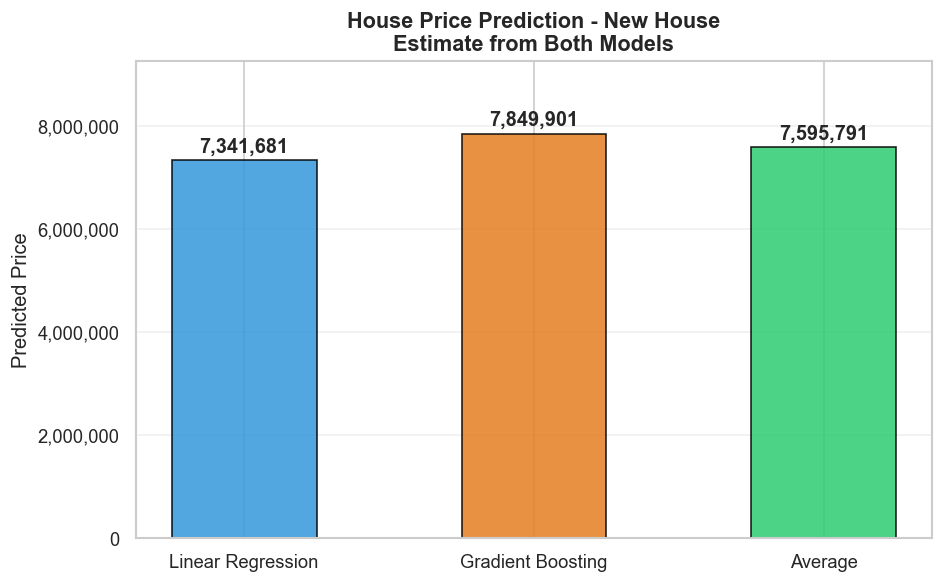

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))

model_names  = ['Linear Regression', 'Gradient Boosting', 'Average']
predictions  = [lr_price, gb_price, (lr_price + gb_price) / 2]
bar_colors   = ['#3498db', '#e67e22', '#2ecc71']

bars = ax.bar(model_names, predictions, color=bar_colors, edgecolor='black', width=0.5, alpha=0.85)

for bar, val in zip(bars, predictions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Predicted Price', fontsize=12)
ax.set_title('House Price Prediction - New House\nEstimate from Both Models',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_ylim(0, max(predictions) * 1.18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('hp_17_single_house_prediction.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.6 Batch Predictions - Multiple Houses

In [37]:
batch_houses = pd.DataFrame([
    {'area':3000,'bedrooms':2,'bathrooms':1,'stories':1,'mainroad':1,'guestroom':0,'basement':0,'hotwaterheating':0,'airconditioning':0,'parking':1,'prefarea':0,'furnishingstatus':0},
    {'area':6000,'bedrooms':4,'bathrooms':3,'stories':3,'mainroad':1,'guestroom':1,'basement':1,'hotwaterheating':1,'airconditioning':1,'parking':2,'prefarea':1,'furnishingstatus':2},
    {'area':4500,'bedrooms':3,'bathrooms':2,'stories':2,'mainroad':1,'guestroom':0,'basement':1,'hotwaterheating':0,'airconditioning':1,'parking':1,'prefarea':0,'furnishingstatus':1},
    {'area':2000,'bedrooms':2,'bathrooms':1,'stories':1,'mainroad':0,'guestroom':0,'basement':0,'hotwaterheating':0,'airconditioning':0,'parking':0,'prefarea':0,'furnishingstatus':0},
    {'area':8000,'bedrooms':5,'bathrooms':4,'stories':4,'mainroad':1,'guestroom':1,'basement':1,'hotwaterheating':1,'airconditioning':1,'parking':3,'prefarea':1,'furnishingstatus':2},
])

# Keep only trained features
batch_houses = batch_houses[[c for c in X.columns if c in batch_houses.columns]]

batch_scaled     = scaler.transform(batch_houses)
batch_lr_preds   = lr_model.predict(batch_scaled)
batch_gb_preds   = gb_model.predict(batch_houses)

batch_results = batch_houses[['area','bedrooms','airconditioning','prefarea']].copy()
batch_results['LR_Price'] = batch_lr_preds.round(0).astype(int)
batch_results['GB_Price'] = batch_gb_preds.round(0).astype(int)
batch_results['Avg_Price'] = ((batch_lr_preds + batch_gb_preds) / 2).round(0).astype(int)
batch_results.index = [f'House {i+1}' for i in range(len(batch_results))]

print("\t\t\t=== BATCH PREDICTION RESULTS ===\n")
print(batch_results.to_string())


			=== BATCH PREDICTION RESULTS ===

         area  bedrooms  airconditioning  prefarea  LR_Price  GB_Price  Avg_Price
House 1  3000         2                0         0   2832905   2264965    2548935
House 2  6000         4                1         1  10080472  11201927   10641200
House 3  4500         3                1         0   6157701   5095520    5626610
House 4  2000         2                0         0   2004476   2604463    2304470
House 5  8000         5                1         1  12359841  13583278   12971560


### 9.7 Batch Price Comparison Chart

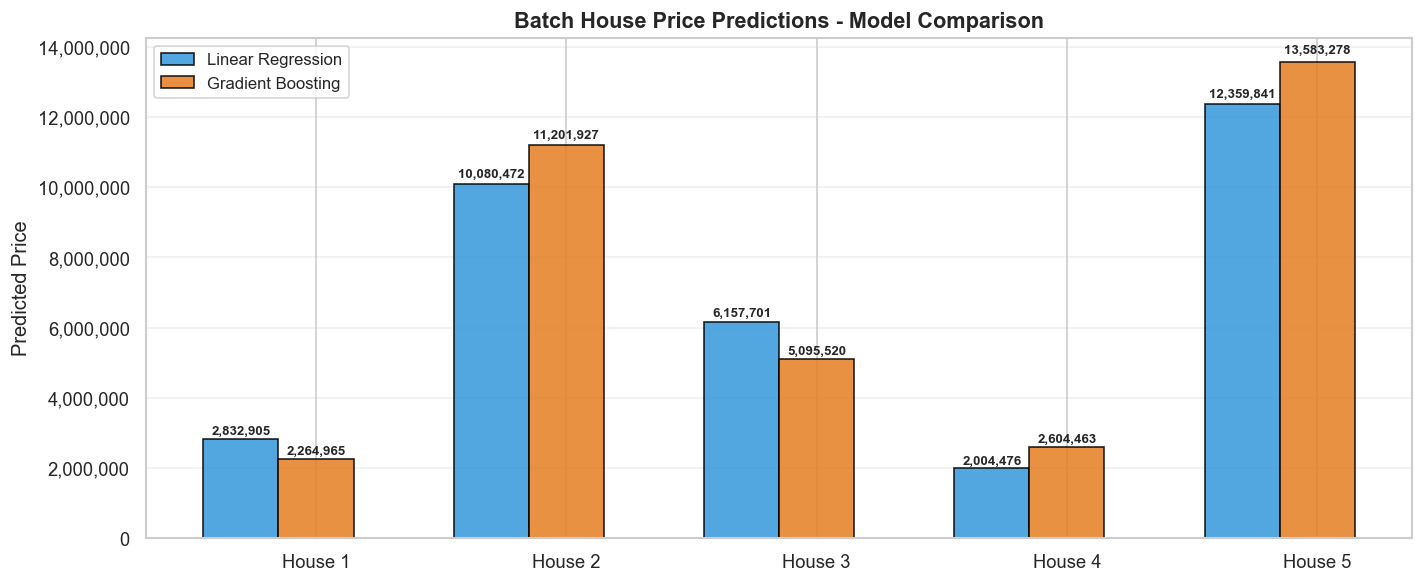

In [42]:
x = np.arange(len(batch_results))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 5))

b1 = ax.bar(x - width, batch_lr_preds, width, label='Linear Regression', color='#3498db', alpha=0.85, edgecolor='black')
b2 = ax.bar(x,          batch_gb_preds, width, label='Gradient Boosting',  color='#e67e22', alpha=0.85, edgecolor='black')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(batch_results.index)
ax.set_ylabel('Predicted Price')
ax.set_title('Batch House Price Predictions - Model Comparison',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('hp_18_batch_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Key Insights and Findings

### Model Performance
- **MAE** tells us the average absolute price error . It is easier to interpret in original units
- **RMSE** penalizes large errors more A model with low RMSE is more consistent
- **R²** tells us what % of price variation the model explains (closer to 1.0 is better)
- Gradient Boosting typically outperforms Linear Regression on tabular data due to its ability to capture non-linear relationships

### Effect of Preprocessing
- Binary categorical features (yes/no) were encoded to 1/0 (required by sklearn models)
- `furnishingstatus` was mapped to ordinal 0/1/2 preserving its natural order
- StandardScaler was applied before Linear Regression to ensure fair feature contribution

### Most Important Features
Based on both models, the strongest price drivers are typically:

| Feature | Effect on Price |
|---|---|
| `area` | Larger area → higher price (strongest driver) |
| `airconditioning` | AC-equipped houses command a premium |
| `prefarea` | Preferred locations significantly boost price |
| `bathrooms` | More bathrooms → higher price |
| `stories` | Multi-floor houses tend to cost more |

### Limitations
- Dataset has limited geographic data. Real estate is highly location-dependent
- No time/trend features. Prices change over years
- A larger dataset with more features (neighborhood, distance to schools, etc.) would improve accuracy


---
## 10. Conclusion

In this project, we successfully:

1. **Loaded and explored** the House Price dataset using pandas
2. **Performed EDA** - price distribution, scatter plots, box plots, correlation heatmap, outlier analysis
3. **Preprocessed data** - categorical encoding with before/after visuals, train/test split, StandardScaler with before/after comparison
4. **Trained two models** - Linear Regression and Gradient Boosting Regressor
5. **Evaluated** using MAE, RMSE, R², actual vs predicted plots, and residual analysis
6. **Analyzed feature importance** - LR coefficients and GB importance scores
7. **Made predictions** - test set results, error distribution, single house estimate with visual, batch predictions

> **Key Takeaway:** `area` is the single most powerful predictor of house price. Gradient Boosting outperforms Linear Regression by capturing non-linear interactions between features like area, location preference, and amenities (AC, parking, furnishing).
